# General imports

In [ ]:
from nf_functions import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 30,           # Dimensione generale del font
    'axes.titlesize': 30,      # Titolo dell'asse
    'axes.labelsize': 30,      # Etichette degli assi
    'legend.fontsize': 20,     # Legenda
    'xtick.labelsize': 30,     # Etichette asse x
    'ytick.labelsize': 30      # Etichette asse y
})


plt.rcParams['text.latex.preamble']=r"\usepackage{lmodern}"
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 30
plt.rcParams['font.family'] = 'lmodern'


# High degree

In [ ]:
from nf_functions import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt

N_PC = 10

Bif = "Pitchfork"

mu = sp.Rational(1, 1)
s = sp.Rational(1, 64)

solutions = []

# Build the necessary matrices and system
F, Variables = Build_system(N_PC, Bif)

G = Build_system_forcing(F, mu, s, Variables, Bif)

solutions = Numerical_system_solver(G, Variables, 100)

least_squares = []

for sol in solutions:
    ls = True
    for i in range(2,N_PC+1):
        if abs(sol[i])>=1e-3:
            ls = False
            break
    if ls is True:
        least_squares.append(sol)


polynomials = Calculate_polynomials(N_PC, mu, s, least_squares, [0 for i in range(len(least_squares))])
# Plot_polynomials_saddle(polynomials, mu, s)
Plot_polynomials(polynomials, N_PC, mu, s, Bif)

sigma = s
expand = True
while expand is True:
    if 2*sigma<=mu:
        sigma = 2*sigma
    else:
        sigma = mu
        expand = False
    H = copy.deepcopy(F) 
    G = Build_system_forcing(H, mu, sigma, Variables, Bif)
    
    solutions = Numerical_system_solver_initial_guesses(G,Variables,least_squares)
    if solutions == []:
        expand = False
    polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, [0 for i in range(len(least_squares))])
    # Plot_polynomials_saddle(polynomials, mu, sigma)
    if expand is False:
        Plot_polynomials(polynomials, N_PC, mu, sigma, Bif, save=True)
    else:
        Plot_polynomials(polynomials, N_PC, mu, sigma, Bif)
    least_squares = solutions

In [ ]:
from nf_functions import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt

N_PC = 10

Bif = "Pitchfork"

mu = sp.Rational(1, 1)
s = sp.Rational(1, 64)

solutions = []

# Build the necessary matrices and system
F, Variables = Build_system(N_PC, Bif)

G = Build_system_forcing(F, mu, s, Variables, Bif)

solutions = Numerical_system_solver(G, Variables, 1000)

least_squares = []

for sol in solutions:
    ls = True
    for i in range(2,N_PC+1):
        if abs(sol[i])>=1e-3:
            ls = False
            break
    if ls is True:
        least_squares.append(sol)


polynomials = Calculate_polynomials(N_PC, mu, s, least_squares, [0 for i in range(len(least_squares))])
# Plot_polynomials_saddle(polynomials, mu, s)
Plot_polynomials(polynomials, N_PC, mu, s, Bif)

sigma = s
counter = 0
while counter<10:
    H = copy.deepcopy(F) 
    G = Build_system_forcing(H, mu, sigma, Variables, Bif)
    
    solutions = Numerical_system_solver_initial_guesses(G,Variables,least_squares)
    if solutions == []:
        expand = False
    polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, [0 for i in range(len(least_squares))])
    # Plot_polynomials_saddle(polynomials, mu, sigma)
    Plot_polynomials(polynomials, N_PC, mu, sigma, Bif)
    least_squares = solutions
    sigma = 2*sigma
    counter+=1

# Increase degree and then expand

In [ ]:
from nf_functions import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt

N_PC = 10

Bif = "Pitchfork"       # S: Saddle node, T: Transcritical

mu = sp.Rational(1, 1)
s = sp.Rational(1, 64)

solutions = []

# Build the necessary matrices and system
F_prov, Variables = Build_system(2, Bif)

G = Build_system_forcing(F_prov, mu, s, Variables, Bif)

solutions = Numerical_system_solver(G, Variables, 1000)

least_squares = []

for sol in solutions:
    ls = True
    for i in range(2,3):
        if abs(sol[i])>=1e-3:
            ls = False
            break
    if ls is True:
        least_squares.append(sol.tolist())



polynomials = Calculate_polynomials(N_PC, mu, s, least_squares, [0 for i in range(len(least_squares))])
# Plot_polynomials_saddle(polynomials, mu, s)
Plot_polynomials(polynomials, N_PC, mu, s, Bif)

for i in range(len(least_squares)):
    for j in range(2,N_PC):
        least_squares[i].append(0)

        
F, Variables = Build_system(N_PC, Bif)

sigma = s
counter = 0

while counter<=8:
    H = copy.deepcopy(F) 
    G = Build_system_forcing(H, mu, sigma, Variables, Bif)
    
    solutions = Numerical_system_solver_initial_guesses(G,Variables,least_squares)
    if solutions == []:
        break
    polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, [0 for i in range(len(least_squares))])
    Plot_polynomials(polynomials, N_PC, mu, sigma, Bif, save=True, ls=True)
    least_squares = solutions
    sigma = 2*sigma
    counter+=1

In [ ]:
from nf_functions import *
import sympy as sp
import copy
import matplotlib.pyplot as plt

N0 = 2
Nmax = 10
mu = 1-2/(3**(3/2))
sigma = sp.Rational(1, 64)
epsilon = 1e-3
Smax = 6
Bif = "S"

sigma_mode = "mul"  # Choose sigma update mode: "mul" for multiplicative, "add" for additive
K = 4       # factor for multiplicative update
k = sp.Rational(4,3)*sp.Rational(4, 43)  # increment for additive update

def filter_solutions(solutions, degree, eps):
    filtered = []
    for sol in solutions:
        # Check coefficients c_l for l >= 2 are < eps
        if all(abs(sol[i]) < eps for i in range(2, degree + 1)):
            filtered.append(sol.tolist())
    return filtered

# Step 1: Solve system for initial degree N0
F_prov, Variables = Build_system(N0, Bif)
G = Build_system_forcing(F_prov, mu, sigma, Variables, Bif)
solutions = Numerical_system_solver(G, Variables, 100)

# Filter solutions for initial N0
least_squares = []
for sol in solutions:
    if all(abs(sol[i]) < epsilon for i in range(2, N0 + 1)):
        least_squares.append(sol.tolist())

# Step 2: Increase degree from N0+1 to Nmax
for N in range(N0 + 1, Nmax + 1):
    # Pad solutions with zero coefficients for the new degree
    for sol in least_squares:
        sol.append(0)

    F, Variables = Build_system(N, Bif)
    G = Build_system_forcing(F, mu, sigma, Variables, Bif)
    
    solutions = Numerical_system_solver_initial_guesses(G, Variables, least_squares)
    if not solutions:
        print(f"No solutions at degree {N}, stopping degree increment.")
        break
    
    # Filter oscillating solutions here
    least_squares = filter_solutions(solutions, N, epsilon)
    if not least_squares:
        print(f"All solutions discarded due to oscillations at degree {N}.")
        break
    
    polynomials = Calculate_polynomials(Nmax, mu, sigma, least_squares, [0] * len(least_squares))
    # Plot_polynomials(polynomials, Nmax, mu, sigma, Bif)

# Step 3: Parameter continuation in sigma (no filtering here)
F, Variables = Build_system(Nmax, Bif)
count = 0
while count < Smax:
    G = Build_system_forcing(F, mu, sigma, Variables, Bif)
    solutions = Numerical_system_solver_initial_guesses(G, Variables, least_squares)
    if not solutions:
        print(f"No solutions at sigma={sigma}, stopping parameter continuation.")
        break
    
    least_squares = solutions  # no filtering
    
    polynomials = Calculate_polynomials(Nmax, mu, sigma, least_squares, [0] * len(least_squares))
    
    
    Plot_polynomials(polynomials, Nmax, mu, sigma, Bif, save = True, ls = True)
    
    if sigma_mode == "mul":
        sigma *= K
    elif sigma_mode == "add":
        sigma += k 
    else:
        raise ValueError("Invalid sigma_mode, choose 'mul' or 'add'.")
    
    count += 1


# Expand and then increase degree

In [ ]:
from nf_functions import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt

N_PC = 6
Bif = "P"       # S: Saddle node, T: Transcritical, P: Pitchfork
mu = sp.Rational(1, 4)
s = sp.Rational(1, 64)


# Build the necessary matrices and system
F_prov, Variables = Build_system(2, Bif)

G = Build_system_forcing(F_prov, mu, s, Variables, Bif)

solutions = Numerical_system_solver(G, Variables, 100)

least_squares = []

for sol in solutions:
    ls = True
    for i in range(2,3):
        if abs(sol[i])>=1e-3:
            ls = False
            break
    if ls is True:
        least_squares.append(sol.tolist())
        
F, Variables = Build_system(2, Bif)

sigma = s
counter = 0
ratio = 1.37
while counter<11:
    H = copy.deepcopy(F) 
    G = Build_system_forcing(H, mu, sigma, Variables, Bif)
    prov_solutions = Numerical_system_solver_initial_guesses(G,Variables,least_squares)
    if prov_solutions == []:
        break
    solutions = prov_solutions
    #polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, [0 for i in range(len(least_squares))])
    #Plot_polynomials(polynomials, mu, sigma, Bif)
    least_squares = solutions
    sigma = ratio*sigma
    counter+=1
sigma = sigma/ratio
polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, [0 for i in range(len(least_squares))])
Plot_polynomials(polynomials, mu, sigma, Bif)
least_squares = [least_squares[i].tolist() for i in range(len(least_squares))]

for i in range(3, N_PC+1):
    for j in range(0, len(least_squares)):
        least_squares[j].append(0)
    F , Variables = Build_system(i, Bif)
    G = Build_system_forcing(F, mu, sigma, Variables, Bif)
    solutions = Numerical_system_solver_initial_guesses(G,Variables,least_squares)
    if solutions == []:
        break
    polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, [0 for i in range(len(least_squares))])
    Plot_polynomials(polynomials, mu, sigma, Bif)
    least_squares = [list(solutions[k]) for k in range(len(solutions))]

# Coefficients study

In [ ]:
from nf_functions import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt
from scipy.special import legendre
from scipy.integrate import quad

import matplotlib.ticker as ticker


bluemathlab="#065895"
orangemathlab="#f79a25"

N_PC = 30
Bif = "Saddle"       # S: Saddle node, T: Transcritical, P: Pitchfork
mu = sp.Rational(11, 10)
s = sp.Rational(1, 64)


# Build the necessary matrices and system
F_prov, Variables = Build_system(2, Bif)

G = Build_system_forcing(F_prov, mu, s, Variables, Bif)

solutions = Numerical_system_solver(G, Variables, 100)

least_squares = []

for sol in solutions:
    ls = True
    for i in range(2,3):
        if abs(sol[i])>=1e-3:
            ls = False
            break
    if ls is True:
        least_squares.append(sol.tolist())
        
F, Variables = Build_system(2, Bif)

sigma = s
counter = 0

while sigma<=sp.Rational(1,1):
    H = copy.deepcopy(F) 
    G = Build_system_forcing(H, mu, sigma, Variables, Bif)
    
    solutions = Numerical_system_solver_initial_guesses(G,Variables,least_squares)
    if solutions == []:
        break
    #polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, [0 for i in range(len(least_squares))])
    #Plot_polynomials(polynomials, mu, sigma, Bif)
    least_squares = solutions
    sigma = 2*sigma
    counter+=1
sigma = sigma/2
polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, [0 for i in range(len(least_squares))])
#Plot_polynomials(polynomials, mu, sigma, Bif)
least_squares = [least_squares[i].tolist() for i in range(len(least_squares))]

a = mu-sigma
b = mu+sigma
def f(x):
    return np.sqrt(float(x))
def x(t,a,b):
    return 0.5 * (b - a) * t + 0.5 * (b + a)

def coefficients(n,a,b):
    coeff = []
    for k in range(n + 1):
        Phi_k = legendre(k)  # Polinomio di Legendre di grado k

        # Funzione integranda dopo il cambiamento di variabile
        integrand = lambda t: f(x(t,a,b)) * Phi_k(t)

        # Calcolo dell'integrale su [-1, 1]
        integral, _ = quad(integrand, -1, 1)

        # Calcolo del coefficiente a_k
        a_k = (2 * k + 1) / 2 * integral
        coeff.append(a_k)
    return coeff

index = 0
for k in range(1,len(least_squares)):
    if least_squares[k][0]>=least_squares[k-1][0]:
        index = k
coeff = coefficients(2,a,b)

residuals_per_order = []
F_eval = [f_i.subs(dict(zip(Variables, coeff))) for f_i in G]
F_eval_numeric = [float(f_i.evalf()) for f_i in F_eval]
residual = np.linalg.norm(F_eval_numeric)
residuals_per_order.append((i, residual))

# Nuova struttura dati: mappa da k → (ordini, errori)
coeff_errors = {}

sse_per_order=[]

# Primo ordine (N=2)
sse = 0
for k in range(len(coeff)):
    abs_err = abs(least_squares[index][k] - coeff[k])
    rel_err = abs(least_squares[index][k] - coeff[k])/abs(coeff[k])
    sse += 2*(abs_err**2)/(2*k+1)
    if k not in coeff_errors:
        coeff_errors[k] = {'orders': [], 'errors': []}
    coeff_errors[k]['orders'].append(i)
    coeff_errors[k]['errors'].append(rel_err)

sse_per_order.append((2, math.sqrt(sse)))




for i in range(3, N_PC+1):
    for j in range(0, len(least_squares)):
        least_squares[j].append(0)
    F , Variables = Build_system(i, Bif)
    G = Build_system_forcing(F, mu, sigma, Variables, Bif)
    print(i)
    solutions = Numerical_system_solver_initial_guesses(G,Variables,least_squares)
    if solutions == []:
        break
    polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, [0 for i in range(len(least_squares))])
    #Plot_polynomials(polynomials, mu, sigma, Bif)
    least_squares = [list(solutions[k]) for k in range(len(solutions))]
    index = 0
    for k in range(1,len(least_squares)):
        if least_squares[k][0]>=least_squares[k-1][0]:
            index = k
    coeff = coefficients(i,a,b)
    
    F_eval = [f_i.subs(dict(zip(Variables, coeff))) for f_i in G]
    F_eval_numeric = [float(f_i.evalf()) for f_i in F_eval]
    residual = np.linalg.norm(F_eval_numeric)
    residuals_per_order.append((i, residual))

    sse = 0
    for k in range(len(coeff)):
        abs_err = abs(least_squares[index][k] - coeff[k])
        rel_err = abs(least_squares[index][k] - coeff[k]) / abs(coeff[k])
        sse += (abs_err**2)/(2*k+1)
        if k not in coeff_errors:
            coeff_errors[k] = {'orders': [], 'errors': []}
        coeff_errors[k]['orders'].append(i)
        coeff_errors[k]['errors'].append(rel_err)

    sse_per_order.append((i, math.sqrt(sse)))
    


import matplotlib.cm as cm

# cmap = cm.get_cmap('tab10')  # Puoi cambiare colormap se hai molti coefficienti

# fig, ax = plt.subplots(1,1, figsize=(10,7))
# for k, data in coeff_errors.items():
#     color = cmap(k % 10)
#     ax.plot(data['orders'], data['errors'], '-o', color=color)
# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.set_xlabel("$N_{PC}$")
# ax.set_ylabel("Relative error")
# ax.grid(True, which="both", linestyle="--", alpha=0.5)
# fig.savefig(f"Plots/Least_squares_coefficients_{N_PC}_{float(mu)}_{float(sigma)}_log.png",bbox_inches='tight')

# cmap = cm.get_cmap('tab10')  # Puoi cambiare colormap se hai molti coefficienti

# fig, ax = plt.subplots(1,1, figsize=(10,7))
# for k, data in coeff_errors.items():
#     color = cmap(k % 10)
#     ax.plot(data['orders'], data['errors'], '-o', color=color)
# ax.set_yscale("log")
# ax.set_xlabel("$N_{PC}$")
# ax.set_ylabel("Relative error")
# ax.grid(True, which="both", linestyle="--", alpha=0.5)
# fig.savefig(f"Plots/Least_squares_coefficients_{N_PC}_{float(mu)}_{float(sigma)}.pdf",bbox_inches='tight')

orders, sse_values = zip(*sse_per_order)
orders_resid, residuals = zip(*residuals_per_order)

orders = np.asarray(orders, dtype=float)
sse_values = np.asarray(sse_values, dtype=float)

alpha = 0.5
C = sse_values[0] * np.exp(alpha * orders[0])
print(f"C={C}")
exp_decay = C * np.exp(-alpha * orders)

pol_decay= sse_values[0]*orders[0]**2/orders**2

fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.plot(orders, sse_values, '-o', color=bluemathlab, label='$\|u_{LS,N}-u_N\|_{L^2}$')
ax.plot(orders_resid, residuals, '-o', color=orangemathlab, label='$\|f(u_{LS,N})\|_{L^2}$')
ax.plot(orders, exp_decay, '--', color='black', label='$Ce^{-N}$')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$N_{PC}$")
ax.legend(loc='lower left')
ax.grid(True, axis="both", which="both", linestyle="--", alpha=0.5)
fig.savefig(f"Plots/Least_squares_SSE_residuals_{N_PC}_{float(mu)}_{float(sigma)}_log.pdf",bbox_inches='tight')


# Estrai ordini e valori del residuo

fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.plot(orders, sse_values, '-o', color=bluemathlab, label='$\|u_{LS,N}-u_N\|_{L^2}$')
ax.plot(orders_resid, residuals, '-o', color=orangemathlab, label='$\|f(u_{LS,N})\|_{L^2}$')
ax.plot(orders, exp_decay, '--', color='black', label='$Ce^{-N}$')
ax.set_yscale("log")
ax.set_xlabel("$N_{PC}$")
ax.legend(loc='lower left')
ax.grid(True, axis="both", which="both", linestyle="--", alpha=0.5)
fig.savefig(f"Plots/Least_squares_SSE_residuals_{N_PC}_{float(mu)}_{float(sigma)}.pdf",bbox_inches='tight')

# Other codes

In [ ]:
from nf_functions import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt

N_PC = 2

Bif = "Saddle"       # S: Saddle node, T: Transcritical

mu = sp.Rational(1, 1)
sigma = sp.Rational(1, 1)

solutions = []
for i in range(1,4):
    # Build the necessary matrices and system
    F_prov, Variables = Build_system(i, Bif)
    # F = Cubic_Factor_Values(2)
    # Variables = [sp.symbols(f'c{i}') for i in range(0, 3)]
    # Variables = np.array(Variables)
    G = Build_system_forcing(F_prov, mu, sigma, Variables, Bif)

    solutions = Numerical_system_solver(G, Variables, 100)
    print(np.matrix(solutions))

# Start from 0

In [ ]:
from nf_functions import *
import sympy as sp
import copy
import matplotlib.pyplot as plt

N0 = 0
Nmax = 10
# mu = sp.Rational(0, 1)
# sigma = sp.Rational(1, 4)
mu = 1-2/(3**(3/2))
sigma = sp.Rational(1, 64)
epsilon = 1e-3
Smax = 15
Bif = "S"

sigma_mode = "add"  # Choose sigma update mode: "mul" for multiplicative, "add" for additive
K = 2       # factor for multiplicative update
k = sp.Rational(4,3)*sp.Rational(4, 43)  # increment for additive update

# Step 1: Solve system for initial degree N0
F_prov, Variables = Build_system(N0, Bif)
G = Build_system_forcing(F_prov, mu, sigma, Variables, Bif)
solutions = Numerical_system_solver(G, Variables, 100)

# Filter solutions for initial N0
least_squares = []
for sol in solutions:
    if all(abs(sol[i]) < epsilon for i in range(2, N0 + 1)):
        least_squares.append(sol.tolist())
polynomials = Calculate_polynomials(Nmax, mu, sigma, least_squares, [0] * len(least_squares))
Plot_polynomials(polynomials, Nmax, mu, sigma, Bif)

# Step 2: Increase degree from N0+1 to Nmax
for N in range(N0 + 1, Nmax + 1):
    # Pad solutions with zero coefficients for the new degree
    for sol in least_squares:
        sol.append(0)

    F, Variables = Build_system(N, Bif)
    G = Build_system_forcing(F, mu, sigma, Variables, Bif)
    
    solutions = Numerical_system_solver_initial_guesses(G, Variables, least_squares)
    if not solutions:
        print(f"No solutions at degree {N}, stopping degree increment.")
        break
    
    # Filter oscillating solutions here
    least_squares = []
    for sol in solutions:
        if all(abs(sol[i]) < epsilon for i in range(2, N0 + 1)):
            least_squares.append(sol.tolist())
    if not least_squares:
        print(f"All solutions discarded due to oscillations at degree {N}.")
        break
    
    polynomials = Calculate_polynomials(Nmax, mu, sigma, least_squares, [0] * len(least_squares))
    Plot_polynomials(polynomials, Nmax, mu, sigma, Bif)

# Step 3: Parameter continuation in sigma (no filtering here)
F, Variables = Build_system(Nmax, Bif)
count = 0
while count < Smax:
    G = Build_system_forcing(F, mu, sigma, Variables, Bif)
    solutions = Numerical_system_solver_initial_guesses(G, Variables, least_squares)
    if not solutions:
        print(f"No solutions at sigma={sigma}, stopping parameter continuation.")
        break
    
    least_squares = solutions  # no filtering
    
    polynomials = Calculate_polynomials(Nmax, mu, sigma, least_squares, [0] * len(least_squares))
    
    
    Plot_polynomials(polynomials, Nmax, mu, sigma, Bif, save = True, ls = True)
    
    if sigma_mode == "mul":
        sigma *= K
    elif sigma_mode == "add":
        sigma += k 
    else:
        raise ValueError("Invalid sigma_mode, choose 'mul' or 'add'.")
    
    count += 1


# Pitchfork

In [ ]:
from nf_functions import *
import sympy as sp
import numpy as np
import copy
import math
import matplotlib.pyplot as plt
from scipy.special import legendre
from scipy.integrate import quad
import os

# Setup directory
os.makedirs("plots", exist_ok=True)

# Colours
bluemathlab="#065895"
orangemathlab="#f79a25"
greenmathlab="#77ac30"

# Parameters and cases to tes
N_PC = 15
Bif = "Pitchfork"
cases=[(sp.Rational(3, 5), sp.Rational(2, 5), "No_Bifurcation"),
       (sp.Rational(1, 2), sp.Rational(1, 2), "Bifurcation_Extremum"),
       (sp.Rational(1, 1), sp.Rational(2, 1), "Bifurcation_Interval")]

def sqrt_zero(x):
    return np.sqrt(x) if x > 0 else 0.0

def mu_transform(t, a, b):
    return 0.5*(b-a)*t+0.5*(b+a)

def get_least_squares_coeffs(n, a, b):
    coeff=[]
    for k in range(n+1):
        Phi_k = legendre(k)
        integrand = lambda t: sqrt_zero(mu_transform(t, a, b))*Phi_k(t)
        integral, _ = quad(integrand, -1, 1)
        a_k = (2*k+1)/2*integral
        coeff.append(a_k)
    return coeff

for mu_val, sigma_val, case_name in cases:
    print(f"\n--- Analysing: {case_name} ---")
    a, b = float(mu_val-sigma_val), float(mu_val+sigma_val)
    xi_vals = np.linspace(-1, 1, 500)
    mu_vals = mu_transform(xi_vals, a, b)
    exact_vals = np.array([sqrt_zero(mu) for mu in mu_vals])
    
    stats = {'n': [], 'sse': [], 'linfty': [], 'res_least_squares': []}
    evolution_approx = []
    current_galerkin_coeffs = []

    for n in range(0, N_PC + 1):
        print(f"Computing N={n} solution...")
        
        c_least_squares = get_least_squares_coeffs(n, a, b)
        Fn, Varn = Build_system(n, Bif)
        Gn = Build_system_forcing(Fn, mu_val, sigma_val, Varn, Bif)
        
        if n==0:
            # Base case: full solver, no initial guesses
            sols = Numerical_system_solver(Gn, Varn, 100)
            current_galerkin_coeffs = [max([s[0] for s in sols])]
        else:
            # Higher degree: use previous degree as initial guess
            current_galerkin_coeffs.append(0.0) 
            sol_n = Numerical_system_solver_initial_guesses(Gn, Varn,
                                                            [current_galerkin_coeffs])
            if not sol_n:
                break
            current_galerkin_coeffs = list(sol_n[0])
        
        # Evaluations for all degrees
        F_eval_least_squares = [f_i.subs(dict(zip(Varn, c_least_squares))) for f_i in Gn]
        res_norm_least_squares = np.linalg.norm([float(f_i.evalf()) for f_i in F_eval_least_squares])
        
        approx_grid = np.zeros_like(xi_vals)
        sse = 0
        for k in range(n+1):
            approx_grid += current_galerkin_coeffs[k]*legendre(k)(xi_vals)
            sse += 2*((current_galerkin_coeffs[k]-c_least_squares[k])**2)/(2*k+1)
        
        stats['n'].append(n)
        stats['sse'].append(math.sqrt(sse))
        stats['linfty'].append(np.max(np.abs(exact_vals-approx_grid)))
        stats['res_least_squares'].append(res_norm_least_squares)
        evolution_approx.append((n, approx_grid))

    # Plot of consistency and convergence verification
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    n_arr = np.array(stats['n'])
    
    ax1.plot(n_arr, stats['sse'], '-o', color=bluemathlab, label=r'$\|u_{LS,N}-u_N\|_{L^2}$')
    ax1.plot(n_arr, stats['linfty'], '-s', color=greenmathlab, label=r'$\|u_{LS,N}-u_N\|_{L^\infty}$')
    ax1.plot(n_arr, stats['res_least_squares'], '-^', color=orangemathlab, label=r'$\|f(u_{LS,N})\|_{L^2}$')

    C_ref_exp = stats['sse'][0]
    if case_name == "No_Bifurcation":
        ax1.plot(n_arr, 0.05* np.exp(-1.2 * (n_arr - n_arr[0])), '-.', color='black', alpha=0.8)

    else:
        if len(n_arr) > 1:
            n_ref = n_arr[1:]
            C_ref_poly = stats['sse'][1] # Anchor C to the N=1 error value
            C_ref_poly_inf = 0.7
            if case_name == "Bifurcation_Extremum":
                ax1.plot(n_ref, 0.04 * (n_ref/n_ref[0])**(-1.0), '--', color='black', alpha=0.8)
                ax1.plot(n_ref, C_ref_poly_inf * (n_ref/n_ref[0])**(-1.0), '--', color='black', alpha=0.8)
                ax1.plot(n_ref, 0.03 * (n_ref/n_ref[0])**(-2.0), ':', color='black', alpha=0.8)
            else:
                ax1.plot(n_ref, 0.1 * (n_ref/n_ref[0])**(-0.5), '--.', color='black', alpha=0.8)
                ax1.plot(n_ref, C_ref_poly_inf * (n_ref/n_ref[0])**(-0.5), '--.', color='black', alpha=0.8)
                ax1.plot(n_ref, 0.09 * (n_ref/n_ref[0])**(-1.0), '--', color='black', alpha=0.8)


    ax1.set_yscale('log')
    ax1.set_xlabel("$N$")
    ax1.legend(loc='lower left')
    ax1.grid(True, which="both", linestyle="--", alpha=0.3)
    fig1.tight_layout()
    fig1.savefig(f"plots/Convergence_{case_name}.pdf")
    plt.show()

    # Plot of approximate solutions vs exact solution
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    ax2.plot(mu_vals, exact_vals, 'k', linewidth=4.0, label=r'$\bar{u}$', zorder=1)
    
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(evolution_approx)))
    
    for i, (n_val, approx) in enumerate(evolution_approx):
        if n_val == N_PC:
            ax2.plot(mu_vals, approx, color=colors[i], linewidth=2.0, zorder=5, linestyle='--',
                     marker='o', markersize=6, markevery=30, label=rf'$u_{{{n_val}}}$')
        else:
            ax2.plot(mu_vals, approx, color=colors[i], linewidth=1.5, linestyle='--', alpha=0.6, zorder=2)

    ax2.set_xlabel(r"$\mu$")
    ax2.set_ylabel(r"$u$")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    fig2.tight_layout()
    fig2.savefig(f"plots/Approximation_{case_name}.pdf")
    plt.show()


--- Analysing: SShaped_Unique ---
Computing N=0 solution...


Solving: 100%|██████████| 100/100 [00:00<00:00, 5715.09it/s]


Computing N=1 solution...


Solving: 100%|██████████| 1/1 [00:00<00:00, 517.50it/s]


Computing N=2 solution...


...

Solving: 100%|██████████| 1/1 [00:00<00:00, 35.32it/s]


Computing N=14 solution...


Solving: 100%|██████████| 1/1 [00:00<00:00, 16.25it/s]


Computing N=15 solution...


Solving: 100%|██████████| 1/1 [00:00<00:00, 24.83it/s]


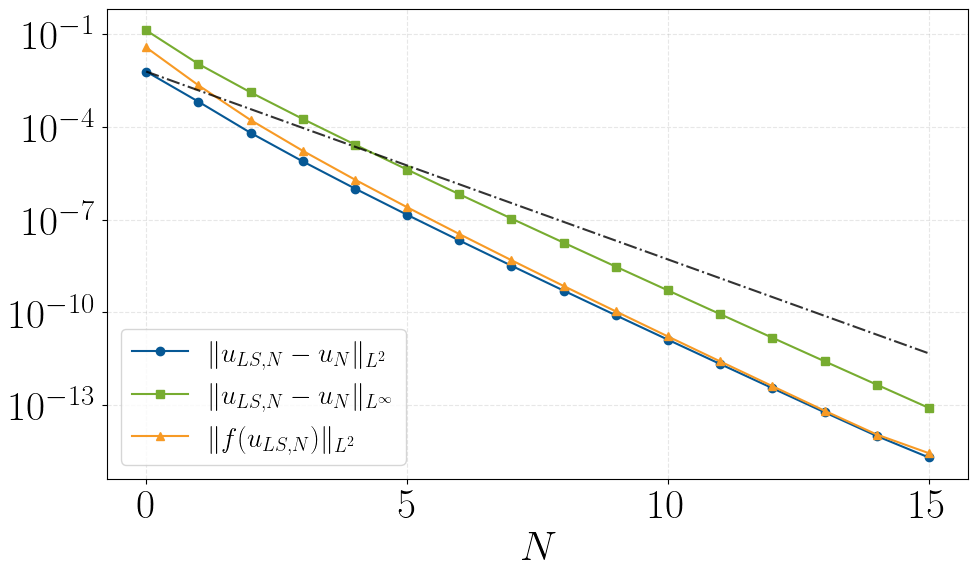

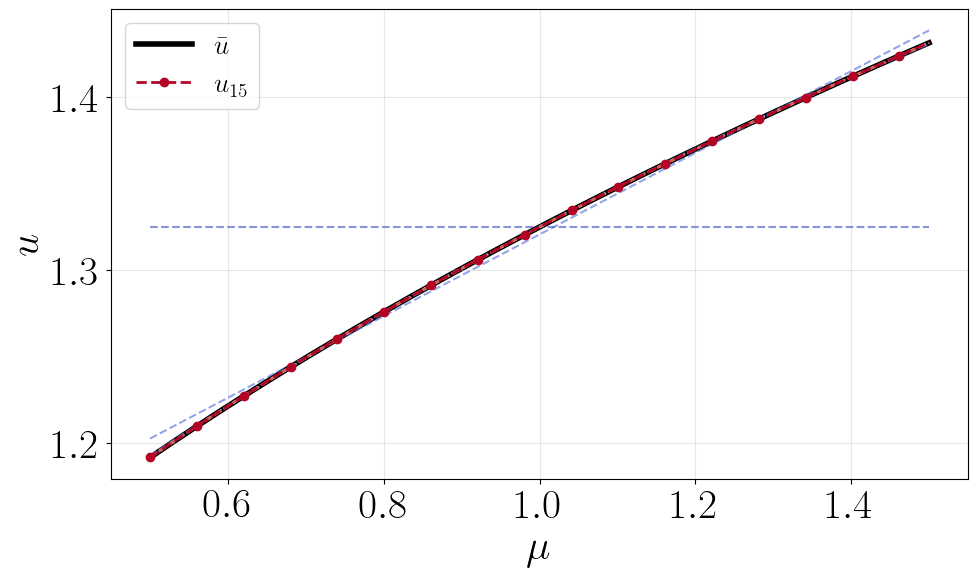

In [29]:
from nf_functions import *
import sympy as sp
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.special import legendre
from scipy.integrate import quad
import os

# Setup directory
os.makedirs("plots", exist_ok=True)

# Colours
bluemathlab="#065895"
orangemathlab="#f79a25"
greenmathlab="#77ac30"

# Parameters and cases to test
N_PC = 15
Bif = "S" # IMPORTANT: Change this to whatever string nf_functions.py expects for u^3 - u - mu

# S-Shaped unique regime: mu_bar = 1.0, sigma = 0.5 -> I = [0.5, 1.5]
cases = [(1.0, 0.5, "SShaped_Unique")]

def exact_s_shaped(mu):
    # Computes the exact real root of u^3 - u - mu = 0
    # For mu > 0.385, there is only one real root.
    roots = np.roots([1, 0, -1, -mu])
    real_roots = roots[np.isclose(roots.imag, 0, atol=1e-7)].real
    # np.max reliably returns the upper stable branch for positive mu
    return float(np.max(real_roots))

def mu_transform(t, a, b):
    return 0.5*(b-a)*t+0.5*(b+a)

def get_least_squares_coeffs(n, a, b):
    coeff=[]
    for k in range(n+1):
        Phi_k = legendre(k)
        integrand = lambda t: exact_s_shaped(mu_transform(t, a, b))*Phi_k(t)
        integral, _ = quad(integrand, -1, 1)
        a_k = (2*k+1)/2*integral
        coeff.append(a_k)
    return coeff

for mu_val, sigma_val, case_name in cases:
    print(f"\n--- Analysing: {case_name} ---")
    a, b = float(mu_val-sigma_val), float(mu_val+sigma_val)
    xi_vals = np.linspace(-1, 1, 500)
    mu_vals = mu_transform(xi_vals, a, b)
    exact_vals = np.array([exact_s_shaped(mu) for mu in mu_vals])
    
    stats = {'n': [], 'sse': [], 'linfty': [], 'res_least_squares': []}
    evolution_approx = []
    current_galerkin_coeffs = []

    for n in range(0, N_PC + 1):
        print(f"Computing N={n} solution...")
        
        c_least_squares = get_least_squares_coeffs(n, a, b)
        Fn, Varn = Build_system(n, Bif)
        Gn = Build_system_forcing(Fn, mu_val, sigma_val, Varn, Bif)
        
        if n==0:
            # Base case: full solver, no initial guesses
            sols = Numerical_system_solver(Gn, Varn, 100)
            current_galerkin_coeffs = [max([s[0] for s in sols])]
        else:
            # Higher degree: use previous degree as initial guess
            current_galerkin_coeffs.append(0.0) 
            sol_n = Numerical_system_solver_initial_guesses(Gn, Varn,
                                                            [current_galerkin_coeffs])
            if not sol_n:
                break
            current_galerkin_coeffs = list(sol_n[0])
        
        # Evaluations for all degrees
        F_eval_least_squares = [f_i.subs(dict(zip(Varn, c_least_squares))) for f_i in Gn]
        res_norm_least_squares = np.linalg.norm([float(f_i.evalf()) for f_i in F_eval_least_squares])
        
        approx_grid = np.zeros_like(xi_vals)
        sse = 0
        for k in range(n+1):
            approx_grid += current_galerkin_coeffs[k]*legendre(k)(xi_vals)
            sse += 2*((current_galerkin_coeffs[k]-c_least_squares[k])**2)/(2*k+1)
        
        stats['n'].append(n)
        stats['sse'].append(math.sqrt(sse))
        stats['linfty'].append(np.max(np.abs(exact_vals-approx_grid)))
        stats['res_least_squares'].append(res_norm_least_squares)
        evolution_approx.append((n, approx_grid))

    # Plot of consistency and convergence verification
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    n_arr = np.array(stats['n'])
    
    ax1.plot(n_arr, stats['sse'], '-o', color=bluemathlab, label=r'$\|u_{LS,N}-u_N\|_{L^2}$')
    ax1.plot(n_arr, stats['linfty'], '-s', color=greenmathlab, label=r'$\|u_{LS,N}-u_N\|_{L^\infty}$')
    ax1.plot(n_arr, stats['res_least_squares'], '-^', color=orangemathlab, label=r'$\|f(u_{LS,N})\|_{L^2}$')

    # Exponential reference slope for the analytical regime
    ax1.plot(n_arr, stats['sse'][0] * np.exp(-1.4 * (n_arr - n_arr[0])), '-.', color='black', alpha=0.8)

    ax1.set_yscale('log')
    ax1.set_xlabel("$N$")
    ax1.legend(loc='lower left')
    ax1.grid(True, which="both", linestyle="--", alpha=0.3)
    fig1.tight_layout()
    fig1.savefig(f"plots/Convergence_{case_name}.pdf")
    plt.show()

    # Plot of approximate solutions vs exact solution
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    ax2.plot(mu_vals, exact_vals, 'k', linewidth=4.0, label=r'$\bar{u}$', zorder=1)
    
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(evolution_approx)))
    
    for i, (n_val, approx) in enumerate(evolution_approx):
        if n_val == N_PC:
            ax2.plot(mu_vals, approx, color=colors[i], linewidth=2.0, zorder=5, linestyle='--',
                     marker='o', markersize=6, markevery=30, label=rf'$u_{{{n_val}}}$')
        else:
            ax2.plot(mu_vals, approx, color=colors[i], linewidth=1.5, linestyle='--', alpha=0.6, zorder=2)

    ax2.set_xlabel(r"$\mu$")
    ax2.set_ylabel(r"$u$")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    fig2.tight_layout()
    fig2.savefig(f"plots/Approximation_{case_name}.pdf")
    plt.show()

# N-k

=== ANALISI TEORICA CONTINUA (Pitchfork) ===
Lambda min teorico : 0.0077
Beta Limite Teorico: 260.0000 (Upper Bound: 2/lambda_min)
Beta Asintotico    : 130.0000 (Convergenza reale: 1/lambda_min)
Andamenti Teorici  : L cresce come O(N^1) | Eta crolla come O(N^-s) | h crolla come O(N^1-s) | convergence se h<0.5
N   | Beta         | L                  | Eta                | h                 
---------------------------------------------------------------------------------------------------------
1   | 4.6285       | 5.5860             | 2.04e-02           | 5.27e-01          
2   | 8.4126       | 7.8604   (R: 0.5)  | 9.95e-03 (R: -1.0) | 6.58e-01 (R: 0.3) 
3   | 13.0760      | 10.4000  (R: 0.7)  | 5.55e-03 (R: -1.4) | 7.54e-01 (R: 0.3) 
4   | 18.4325      | 11.8523  (R: 0.5)  | 3.36e-03 (R: -1.7) | 7.35e-01 (R: -0.1)
5   | 24.2250      | 12.1691  (R: 0.1)  | 2.15e-03 (R: -2.0) | 6.33e-01 (R: -0.7)
6   | 30.2648      | 15.5269  (R: 1.3)  | 1.42e-03 (R: -2.3) | 6.68e-01 (R: 0.3) 
7   | 36.

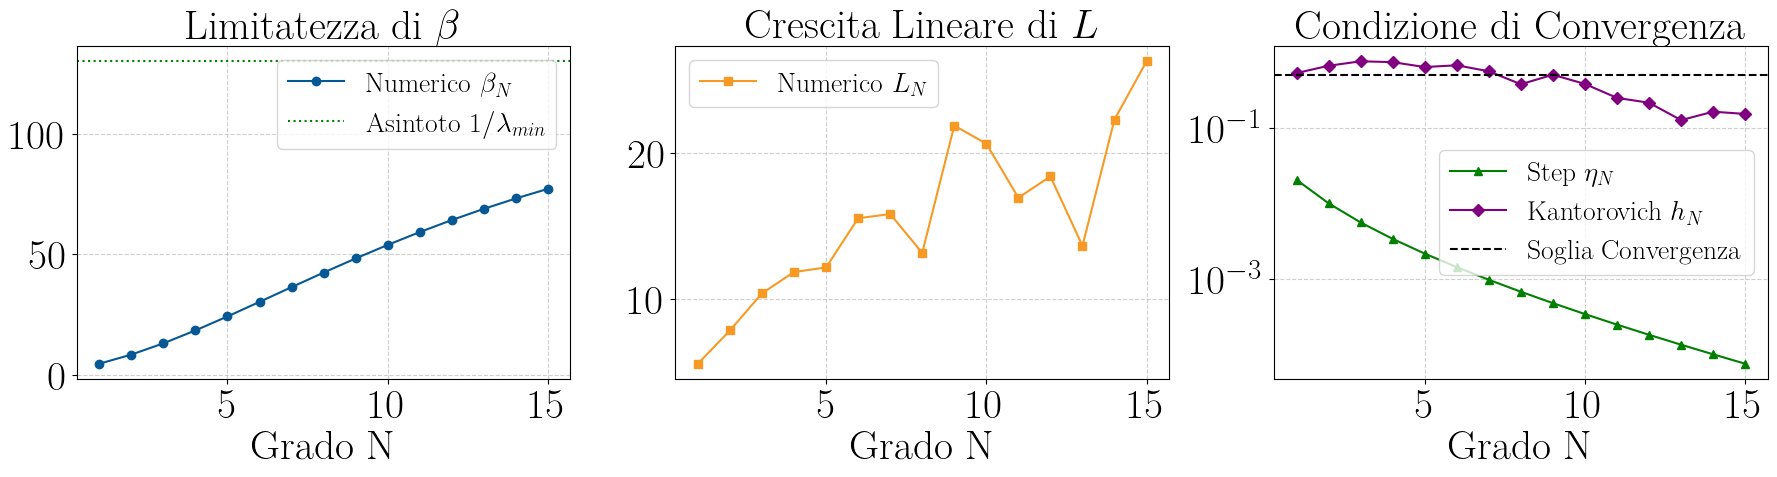

In [26]:
import numpy as np
import sympy as sp
from scipy.special import legendre
from scipy.integrate import quad
from nf_functions import Build_system, Build_system_forcing
import matplotlib.pyplot as plt

# --- 1. SOLUZIONE ESATTA E VALUTATORE ---
def f_exact(x):
    return 0.0 if x <= 0 else np.sqrt(float(x))

def mu_transform(t, a, b):
    return 0.5 * (b - a) * t + 0.5 * (b + a)

def true_coefficients(n, a, b):
    coeff = []
    for k in range(n + 1):
        Phi_k = legendre(k)
        integrand = lambda t: f_exact(mu_transform(t, a, b)) * Phi_k(t)
        integral, _ = quad(integrand, -1, 1)
        coeff.append((2 * k + 1) / 2 * integral)
    return np.array(coeff)

def evaluate_kantorovich_weighted(G_scaled, Variables, x0, radius=0.01, n_samples=50):
    N = len(x0) - 1
    w = np.array([1.0 / (2 * i + 1) for i in range(N + 1)])
    W = np.diag(w)
    W_sqrt = np.diag(np.sqrt(w))
    W_inv_sqrt = np.diag(1.0 / np.sqrt(w))

    def norm_star_vec(v): return np.sqrt(np.dot(v, W @ v))
    def norm_star_mat(A): return np.linalg.norm(W_sqrt @ A @ W_inv_sqrt, ord=2)

    J_sym = sp.Matrix(G_scaled).jacobian(Variables)
    F_func = sp.lambdify([Variables], G_scaled, "numpy")
    J_func = sp.lambdify([Variables], J_sym, "numpy")

    F_x0 = np.array(F_func(x0)).flatten()
    J_x0 = np.array(J_func(x0), dtype=float)
    J_inv = np.linalg.inv(J_x0)

    beta = norm_star_mat(J_inv)
    eta = norm_star_vec(J_inv @ F_x0)

    L_est = 0
    dim = len(x0)
    for _ in range(n_samples):
        x = x0 + np.random.uniform(-radius, radius, dim)
        y = x0 + np.random.uniform(-radius, radius, dim)
        if not np.allclose(x, y):
            norm_diff_J = norm_star_mat(J_func(x) - J_func(y))
            norm_diff_x = norm_star_vec(x - y)
            L_est = max(L_est, norm_diff_J / norm_diff_x)

    h = beta * L_est * eta
    return beta, eta, L_est, h

# --- 2. ESECUZIONE E RACCOLTA DATI ---
N_max = 15
Bif = "Pitchfork"  # S: Saddle node, P: Pitchfork
mu_val = sp.Rational(1, 4)
sigma_val = sp.Rational(16, 65)
a = float(mu_val - sigma_val)
b = float(mu_val + sigma_val)

if Bif in ["Saddle", "S"]:
    lambda_min = 2 * np.sqrt(a)
    beta_teo = 2 / lambda_min
    beta_asintotico = 1 / lambda_min
elif Bif in ["Pitchfork", "P"]:
    lambda_min = 2 * a
    beta_teo = 2 / lambda_min
    beta_asintotico = 1 / lambda_min

print(f"=== ANALISI TEORICA CONTINUA ({Bif}) ===")
print(f"Lambda min teorico : {lambda_min:.4f}")
print(f"Beta Limite Teorico: {beta_teo:.4f} (Upper Bound: 2/lambda_min)")
print(f"Beta Asintotico    : {beta_asintotico:.4f} (Convergenza reale: 1/lambda_min)")
print(f"Andamenti Teorici  : L cresce come O(N^1) | Eta crolla come O(N^-s) | h crolla come O(N^1-s) | convergence se h<0.5")
print("=" * 105)
print(f"{'N':<3} | {'Beta':<12} | {'L':<18} | {'Eta':<18} | {'h':<18}")
print("-" * 105)

orders, betas, Ls, etas, hs = [], [], [], [], []
prev_L, prev_eta, prev_h = None, None, None

for N in range(1, N_max + 1):
    F_prov, Variables = Build_system(N, Bif)
    G = Build_system_forcing(F_prov, mu_val, sigma_val, Variables, Bif)
    
    # Moltiplicazione per 0.5 (misura di probabilità 1/2 dz) e divisione per i pesi ||Phi||^2
    w = np.array([1.0 / (2 * i + 1) for i in range(N + 1)])
    G_theory = [0.5 * G[i] / w[i] for i in range(N + 1)] 
    
    x0_true = true_coefficients(N, a, b)
    beta, eta, L_est, h = evaluate_kantorovich_weighted(G_theory, Variables, x0_true)
    
    rate_L = f"(R: {np.log(L_est/prev_L) / np.log(N/(N-1)):.1f})" if prev_L else ""
    rate_eta = f"(R: {np.log(eta/prev_eta) / np.log(N/(N-1)):.1f})" if prev_eta and prev_eta>0 else ""
    rate_h = f"(R: {np.log(h/prev_h) / np.log(N/(N-1)):.1f})" if prev_h and prev_h>0 else ""
    
    print(f"{N:<3} | {beta:<12.4f} | {L_est:<8.4f} {rate_L:<9} | {eta:<8.2e} {rate_eta:<9} | {h:<8.2e} {rate_h:<9}")
    
    orders.append(N); betas.append(beta); Ls.append(L_est); etas.append(eta); hs.append(h)
    prev_L, prev_eta, prev_h = L_est, eta, h

# --- 3. GRAFICI ---
plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Beta
axs[0].plot(orders, betas, '-o', color='#065895', label=r'Numerico $\beta_N$')
axs[0].axhline(beta_asintotico, color='green', linestyle=':', label=r'Asintoto $1/\lambda_{min}$')
axs[0].set_title(r"Limitatezza di $\beta$")
axs[0].set_xlabel("Grado N")
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: L
axs[1].plot(orders, Ls, '-s', color='#f79a25', label=r'Numerico $L_N$')
axs[1].set_title(r"Crescita Lineare di $L$")
axs[1].set_xlabel("Grado N")
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Eta e h
axs[2].plot(orders, etas, '-^', color='green', label=r'Step $\eta_N$')
axs[2].plot(orders, hs, '-D', color='purple', label=r'Kantorovich $h_N$')
axs[2].axhline(0.5, color='black', linestyle='--', label=r'Soglia Convergenza')
axs[2].set_yscale('log')
axs[2].set_title(r"Condizione di Convergenza")
axs[2].set_xlabel("Grado N")
axs[2].legend()
axs[2].grid(True, which="both", linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Kantorovich_Verification.pdf", bbox_inches='tight')
plt.show()